# 61 — DepMap Cancer Dependency Scout

```text
Reviewer/manuscript concern addressed: is there a clean, defensible HUMAN cancer-dependency
    showcase (DepMap CRISPR gene-effect coessentiality) that could replace or supplement the
    yeast GI-PCC biological-utility case study (notebook 40)? This is a GO/NO-GO feasibility
    scout, not a manuscript figure.
Input files: local CRISPRGeneEffect.csv (DepMap Public 24Q4, inferred from file size/date --
    see Section 1), local Reactome pathway modules (s_cerevisiae repo's homo_sapiens/reactome
    data product) + local Entrez->symbol gene mapping. No new network downloads were required
    (see Section 1 for what WAS checked over the network before this was discovered).
HiMaLAYAS version: verified git tag v0.0.15, activated via revision_utils.activate_pinned_source(),
    the same pattern notebooks 01/10/11/20/21/30/40 established.
Random seed: not applicable -- clustering/enrichment is deterministic given its config; no
    stochastic resampling is performed in this notebook.
Primary parameters: 1500 highest-variance genes (bounded subset, see Section 3), Pearson
    correlation (PCC) coessentiality matrix, parent config threshold=16/min_cluster_size=15/
    ward/euclidean/min_overlap=2/qval<=0.05, zoom config threshold=6/min_cluster_size=5. One
    conservative exploratory pass only -- no threshold tuning to force a story.
Outputs written:
    revision/outputs/manifests/61_depmap_dependency_scout_manifest.json
    revision/outputs/tables/61_depmap_dependency_scout/*.csv
    revision/outputs/figures/61_depmap_dependency_scout/*.png
    revision/notes/20260727_depmap_dependency_scout_audit.md
Interpretation: see the GO / CONDITIONAL-GO / NO-GO decision in Section 8.
```

## Scope and framing

This notebook is a **bounded feasibility scout**, not a benchmark and not a polished
manuscript figure. Per the task brief it works only inside `revision/`, keeps downloads
minimal and provenance-recorded, uses a single conservative gene subset and threshold
choice (no repeated tuning to force a story), and makes one firm GO/CONDITIONAL-GO/NO-GO
call at the end.

**Safer target claim under test** (per the task brief, not to be exceeded without direct
verification): *HiMaLAYAS provides a compact post hoc annotation and visualization workflow
for human cancer dependency matrices, exposing interpretable pathway/complex structure in
dense coessentiality data.* This notebook explicitly checks any candidate finding against
a real published coessentiality resource (Wainberg et al. 2021, the `coessentiality`
companion modules) before calling anything more than that.

## 1. Locate repo root and import shared revision utilities

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    markers = ("himalayas_src", "data", ".git", "revision")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not locate himalayas-publication repo root above {start}")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "revision" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Kernel CWD:  {Path.cwd()}")
print(f"Repo root:   {REPO_ROOT}")

Kernel CWD:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notebooks
Repo root:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication


In [2]:
import json

import numpy as np
import pandas as pd

import revision_utils as ru
from revision_utils import revision_layout

layout = revision_layout(REPO_ROOT)
for key in ("manifests_dir", "figures_dir", "tables_dir", "scratch_dir"):
    layout[key].mkdir(parents=True, exist_ok=True)

NB_ID = "61_depmap_dependency_scout"
NB_FIGURES_DIR = layout["figures_dir"] / NB_ID
NB_TABLES_DIR = layout["tables_dir"] / NB_ID
NB_SCRATCH_DIR = layout["scratch_dir"] / NB_ID
for d in (NB_FIGURES_DIR, NB_TABLES_DIR, NB_SCRATCH_DIR):
    d.mkdir(parents=True, exist_ok=True)

NOTES_DIR = layout["revision_dir"] / "notes"
NOTES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures ->", NB_FIGURES_DIR)
print("Tables  ->", NB_TABLES_DIR)
print("Scratch ->", NB_SCRATCH_DIR)
print("Notes   ->", NOTES_DIR)

Figures -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/61_depmap_dependency_scout
Tables  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/61_depmap_dependency_scout
Scratch -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout
Notes   -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notes


## 2. Step 1 — Data access audit (what was checked over the network first)

Before touching any local file, the following public DepMap/coessentiality sources were
checked directly (curl / figshare API), per the task's requirement to record source
URLs/sizes and to stop before any >500 MB download:

| Source checked | Result |
|---|---|
| `depmap.org/portal/data_page` and `/download/all/` | Blocked by Cloudflare bot verification (HTTP 200 but a JS challenge page, no data) from this environment. |
| DepMap forum "Announcing the 26Q1 Release" | Confirms 26Q1 is the current public release (as of 2026-07-27) but the post itself has no direct file links. |
| Figshare item `Chronos_parameters_Public_26Q1_` (id 31660582, confirmed real via the public figshare API) | Contains `gene_effect.csv`, **431.1 MB** -- a legitimate 26Q1 gene-effect matrix, individually under the 500 MB cap, but not used (see next row). |
| `figshare.com/.../DepMap_24Q4_Public/27993248` (public API) | Full file listing obtained. `CRISPRGeneEffect.csv` = **428.7 MB** for the 24Q4 release. Every Omics/expression/mutation file in the same release is 100 MB-4+ GB; none of those were needed or fetched. |
| Kundaje/Bassik lab `coessentiality` GitHub repo (companion to Wainberg et al. 2021, *Nat Genet*, a public coessentiality resource **derived from DepMap**, matching the task's source-type #3) | README + `mitra.stanford.edu` HEAD requests confirm `GLS_p.npy` / `GLS_sign.npy` are **2.49 GB each** (17634x17634 float matrices) -- explicitly a >500 MB download, correctly identified and NOT fetched. |

**Resolution: no network download was needed.** A local, already-downloaded clone of the
`kundajelab/coessentiality` repository was found at
`/Users/irahorecka/Desktop/harddrive_desktop/Python/coessentiality` (outside this repo,
read-only source) containing a `CRISPRGeneEffect.csv` whose size (428,678,699 bytes) and
file-modification date (2025-04-17) exactly match the DepMap 24Q4 Public release identified
above. This is used as the primary human dependency input -- see Section 1b for exact hash
and provenance, and the audit note for the full caveat on release-string confirmation.

### 1b. Provenance record for the local input files

`CRISPRGeneEffect.csv` (model x gene Chronos gene-effect matrix) and `sample_info.csv`
(cell line metadata) are **not tracked by the local git repo** (they show as untracked in
`git status`); they are local DepMap downloads sitting alongside the `coessentiality`
companion code. `clusterOne_clusters.tsv` (Wainberg et al.'s own published module
assignments + top-3 GO-term enrichment per module) **is** part of that repo and is used
below as an independent ground-truth check, not as this notebook's input.

In [3]:
COESSENTIALITY_REPO = Path("/Users/irahorecka/Desktop/harddrive_desktop/Python/coessentiality")
DEPMAP_GENE_EFFECT_PATH = COESSENTIALITY_REPO / "CRISPRGeneEffect.csv"
CLUSTERONE_PATH = COESSENTIALITY_REPO / "clusterOne_clusters.tsv"

assert DEPMAP_GENE_EFFECT_PATH.exists(), f"Missing {DEPMAP_GENE_EFFECT_PATH}"
assert CLUSTERONE_PATH.exists(), f"Missing {CLUSTERONE_PATH}"

depmap_hash = ru.sha256_file(DEPMAP_GENE_EFFECT_PATH)
depmap_size_bytes = DEPMAP_GENE_EFFECT_PATH.stat().st_size
depmap_mtime = DEPMAP_GENE_EFFECT_PATH.stat().st_mtime

print(f"CRISPRGeneEffect.csv path:   {DEPMAP_GENE_EFFECT_PATH}")
print(f"CRISPRGeneEffect.csv sha256: {depmap_hash}")
print(f"CRISPRGeneEffect.csv size:   {depmap_size_bytes:,} bytes")
import datetime

print(f"CRISPRGeneEffect.csv mtime:  {datetime.datetime.fromtimestamp(depmap_mtime)}")

# Size/date cross-check against the DepMap 24Q4 Public figshare listing recorded during
# the network audit (Section 1): CRISPRGeneEffect.csv = 428,700,262-ish bytes (~428.7 MB).
DEPMAP_24Q4_FIGSHARE_SIZE_MB = 428.7
size_mb = depmap_size_bytes / 1e6
print(f"\nLocal file size:  {size_mb:.1f} MB")
print(f"DepMap 24Q4 figshare-listed CRISPRGeneEffect.csv size: {DEPMAP_24Q4_FIGSHARE_SIZE_MB} MB")
release_size_match = abs(size_mb - DEPMAP_24Q4_FIGSHARE_SIZE_MB) < 1.0
print(f"Matches within 1 MB: {release_size_match}")

CRISPRGeneEffect.csv path:   /Users/irahorecka/Desktop/harddrive_desktop/Python/coessentiality/CRISPRGeneEffect.csv
CRISPRGeneEffect.csv sha256: 3d8f3ec6dbf2db7ff834b79b508622ec0b226f3518003fe96ecf5a4fcf167e3b
CRISPRGeneEffect.csv size:   428,678,699 bytes
CRISPRGeneEffect.csv mtime:  2025-04-17 16:47:48

Local file size:  428.7 MB
DepMap 24Q4 figshare-listed CRISPRGeneEffect.csv size: 428.7 MB
Matches within 1 MB: True


**Caveat, stated plainly:** this is a size/date match, not a cryptographic release proof --
the local `CRISPRGeneEffect.csv` has no embedded release-version string. It is treated as
**DepMap Public 24Q4** (released ~December 2024) on the strength of this size match plus the
April 2025 download date (consistent with a download shortly after that release). If a
reviewer needs an exact-DOI-pinned copy, the 24Q4 figshare article (`plus.figshare.com/articles/dataset/DepMap_24Q4_Public/27993248`, DOI
`10.25452/figshare.plus.27993248.v1`) is the citable source to re-download from.

## 2. Step 2 — Load the DepMap gene-effect matrix and clean it

In [4]:
import time

t0 = time.time()
depmap_raw = pd.read_csv(DEPMAP_GENE_EFFECT_PATH, index_col=0)
print(f"Loaded raw matrix: {depmap_raw.shape} (models x genes) in {time.time()-t0:.1f}s")

# DepMap columns are "SYMBOL (Entrez_ID)"; strip to bare gene symbol.
gene_symbols = [c.split(" (")[0] for c in depmap_raw.columns]
n_dupe_roots = len(gene_symbols) - len(set(gene_symbols))
print(f"Duplicate gene-symbol roots after stripping Entrez ID: {n_dupe_roots}")

depmap = depmap_raw.copy()
depmap.columns = gene_symbols
depmap = depmap.loc[:, ~depmap.columns.duplicated()]
print(f"After symbol-collision dedup: {depmap.shape}")

n_genes_before_na_drop = depmap.shape[1]
depmap = depmap.dropna(axis=1, how="any")
print(f"Dropped genes with any missing model score: {n_genes_before_na_drop} -> {depmap.shape[1]}")

n_models_before_na_drop = depmap.shape[0]
depmap = depmap.dropna(axis=0, how="any")
print(
    f"Dropped models with any missing score (should be 0, matrix already dense by column): {n_models_before_na_drop} -> {depmap.shape[0]}"
)

print(f"\nFinal cleaned DepMap matrix: {depmap.shape[0]} models x {depmap.shape[1]} genes")

Loaded raw matrix: (1178, 17916) (models x genes) in 3.0s
Duplicate gene-symbol roots after stripping Entrez ID: 0
After symbol-collision dedup: (1178, 17916)
Dropped genes with any missing model score: 17916 -> 17087
Dropped models with any missing score (should be 0, matrix already dense by column): 1178 -> 1178

Final cleaned DepMap matrix: 1178 models x 17087 genes


## 3. Step 3 — Bounded gene subset (defensible, not tuned)

The full cleaned matrix has ~17,000 genes -- far above the task's 1,000-3,000 gene scout
cap and too large for a single conservative HiMaLAYAS pass. Following the task's guidance
("high-variance dependency genes ... or 1,000-3,000 genes max"), this notebook selects the
**1,500 genes with the highest across-model variance in Chronos gene-effect score**.

**Why this is defensible, not cherry-picked:**
- Variance ranking is computed once, directly from the full cleaned matrix, with no peek
  at downstream clustering/enrichment results before the cutoff was chosen.
- High-variance dependency genes are the standard signal used throughout the DepMap/
  coessentiality literature (including Wainberg et al. 2021, whose GLS-based approach is
  specifically designed around genes with informative across-model variance; purely
  flat, uniformly-essential "common-essential" genes contribute comparatively little
  distinguishing correlation structure and are conventionally down-weighted or excluded
  from module-detection).
- 1,500 sits centrally within the task's stated 1,000-3,000 gene range -- not the minimum
  (which would risk missing structure) or the maximum (which would strain a "conservative,
  single-pass" scout).
- The cutoff (1,500) was fixed **before** any clustering was run, and was not revisited
  after seeing results -- consistent with the task's "do not tune thresholds repeatedly to
  force a story" instruction.

In [5]:
N_GENES = 1500

gene_variance = depmap.var(axis=0, ddof=1).sort_values(ascending=False)
print("Top 10 highest-variance genes (Chronos gene-effect score across models):")
print(gene_variance.head(10))

top_genes = gene_variance.head(N_GENES).index.tolist()
depmap_subset = depmap[top_genes]
print(f"\nBounded subset: {depmap_subset.shape[0]} models x {depmap_subset.shape[1]} genes")

Top 10 highest-variance genes (Chronos gene-effect score across models):
YRDC      0.690141
CCND1     0.613566
EIF1AX    0.504894
INTS6     0.464734
SCAP      0.443720
DNAJC9    0.441820
MYC       0.434678
KIF18A    0.422259
TYMS      0.420008
TUBB      0.418143
dtype: float64

Bounded subset: 1178 models x 1500 genes


## 4. Step 4 — Build the square gene-gene coessentiality (PCC) matrix

This is a **model x gene -> gene-gene PCC** conversion, the same pattern already used for
the yeast GI-PCC case study (`data/yeast/gi_pcc_sampled.tsv`, built from a query x array
qGI matrix). Pairwise Pearson correlation of each gene's across-model dependency profile is
the standard coessentiality construction (Wainberg et al. 2021 uses GLS regression, a
related but more elaborate variant; plain PCC is used here for a conservative, easily
audited single pass, consistent with 'no tuning to force a story').

In [6]:
t1 = time.time()
coessentiality_pcc = depmap_subset.corr(method="pearson")
print(f"Coessentiality PCC matrix: {coessentiality_pcc.shape} computed in {time.time()-t1:.1f}s")

print(f"Any NaN: {coessentiality_pcc.isna().any().any()}")
print(f"Diagonal ~1.0: {np.allclose(np.diag(coessentiality_pcc.values), 1.0)}")
print(f"Symmetric: {np.allclose(coessentiality_pcc.values, coessentiality_pcc.values.T)}")

pcc_path = NB_SCRATCH_DIR / "depmap_coessentiality_pcc_1500.tsv"
coessentiality_pcc.to_csv(pcc_path, sep="\t")
pcc_hash = ru.sha256_file(pcc_path)
print(f"\nWritten to scratch: {pcc_path}")
print(f"sha256: {pcc_hash}")

Coessentiality PCC matrix: (1500, 1500) computed in 1.9s
Any NaN: False
Diagonal ~1.0: True
Symmetric: True



Written to scratch: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout/depmap_coessentiality_pcc_1500.tsv
sha256: 62fa484ab714a23342e93781fabc2598368ee45fb864ca6671a9871142fea6b2


## 5. Step 5 — Human annotation set: Reactome pathways

Per the task's preference order (CORUM/Reactome first, GO BP second), **Reactome** was
used. CORUM's public download endpoint has moved behind a JS-rendered SPA that no longer
serves a static flat-file link from this environment (checked and abandoned quickly, not a
rabbit hole -- Reactome was already confirmed accessible). A local, already-provenanced
Reactome pathway-to-gene mapping was found in a sibling repo's human-genome data product
(`s_cerevisiae/data/fm/homo_sapiens/reactome/final/reactome/modules.json`, 2,870 human
Reactome pathways, acquired 2026-04-23 from Reactome's own SBML export) and used in
preference to a fresh `reactome.org` GMT download, since it is equivalent content with
clearer acquisition metadata already on hand. Gene identifiers there are Entrez IDs; they
are mapped to symbols via a sibling Entrez->symbol mapping table to align with DepMap's
gene-symbol columns.

In [7]:
REACTOME_MODULES_PATH = Path(
    "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/"
    "s_cerevisiae/s_cerevisiae/data/fm/homo_sapiens/reactome/final/reactome/modules.json"
)
GENE_MAPPING_PATH = Path(
    "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/"
    "s_cerevisiae/s_cerevisiae/data/db/external/homo_sapiens/gene_mapping/published/latest/"
    "mapping.json"
)
REACTOME_METADATA_PATH = REACTOME_MODULES_PATH.parent / "metadata.json"

assert REACTOME_MODULES_PATH.exists(), f"Missing {REACTOME_MODULES_PATH}"
assert GENE_MAPPING_PATH.exists(), f"Missing {GENE_MAPPING_PATH}"

reactome_metadata = json.loads(REACTOME_METADATA_PATH.read_text())
print("Reactome data-product metadata (acquisition provenance):")
print(json.dumps(reactome_metadata, indent=2))

reactome_modules_hash = ru.sha256_file(REACTOME_MODULES_PATH)
gene_mapping_hash = ru.sha256_file(GENE_MAPPING_PATH)
print(f"\nmodules.json sha256:  {reactome_modules_hash}")
print(f"mapping.json sha256:  {gene_mapping_hash}")

Reactome data-product metadata (acquisition provenance):
{
  "acquired_at": "2026-04-23T20:14:01Z",
  "endpoints": [
    "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/s_cerevisiae/s_cerevisiae/data/db/external/homo_sapiens/fm/reactome/sbml",
    "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/s_cerevisiae/s_cerevisiae/data/db/external/homo_sapiens/gene_mapping/published/latest/mapping.json"
  ],
  "finalized_at": "2026-06-03T17:41:40Z",
  "record_count": 2870,
  "record_count_final": 2870,
  "record_count_raw": 2870,
  "source": "reactome"
}

modules.json sha256:  f907a40d5acbffb6ad53ede57365e45f86ecd030c0d92d69c13bb0d22389e720
mapping.json sha256:  726f4910525b7ed3916d5271e7786c9f37cbd22de8d16dd61590e1f55ba8999b


In [8]:
gene_mapping = json.loads(GENE_MAPPING_PATH.read_text())
entrez_to_symbol = {
    str(rec["entrez_id"]): rec["symbol"]
    for rec in gene_mapping
    if rec.get("entrez_id") and rec["entrez_id"] > 0 and rec.get("symbol")
}
print(f"Entrez -> symbol pairs available: {len(entrez_to_symbol):,}")

reactome_modules_raw = json.loads(REACTOME_MODULES_PATH.read_text())
print(f"Raw Reactome human pathways: {len(reactome_modules_raw)}")

reactome_term_to_genes = {}
for module in reactome_modules_raw:
    symbols = {entrez_to_symbol.get(g) for g in module["genes"]}
    symbols.discard(None)
    if symbols:
        reactome_term_to_genes[module["name"]] = sorted(symbols)

print(f"Reactome pathways with >=1 resolved gene symbol: {len(reactome_term_to_genes)}")

reactome_terms_path = NB_SCRATCH_DIR / "reactome_symbol_terms.json"
reactome_terms_path.write_text(json.dumps(reactome_term_to_genes))
print(f"Written to scratch: {reactome_terms_path}")

Entrez -> symbol pairs available: 193,636
Raw Reactome human pathways: 2870
Reactome pathways with >=1 resolved gene symbol: 2859
Written to scratch: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout/reactome_symbol_terms.json


## 6. Step 6 — Activate pinned HiMaLAYAS and run one conservative clustering/enrichment pass

In [9]:
himalayas_diagnostics_at_start = ru.himalayas_diagnostics(layout["repo_root"])
print(json.dumps(himalayas_diagnostics_at_start, indent=2, default=str))

{
  "imported_version": "0.0.16a0",
  "imported_file": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/src/himalayas/__init__.py",
  "is_editable_install": true,
  "editable_project_location": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas",
  "editable_git": {
    "is_git_repo": true,
    "branch": "v0.0.16",
    "commit": "0c511157663c7f392d9338e101830c462ce59b9c",
    "describe": "v0.0.15-4-g0c51115",
    "is_dirty": true,
    "dirty_files": [
      "M src/himalayas/__init__.py",
      " M tests/test_dendrogram_condensed.py",
      "?? PREVIEW_NOTES.md",
      "?? _archive/",
      "?? preview-release-notes.sh",
      "?? scratch/",
      "?? test.py"
    ]
  },
  "vendored_copy_path": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/himalayas_src/himalayas/__init__.py",
  "vendored_copy_version": "0.0.15",
  "readme_pinned_ve

In [10]:
PINNED_TAG = "v0.0.15"

try:
    activation = ru.activate_pinned_source(
        layout["repo_root"], NB_SCRATCH_DIR / "himalayas_pinned_v0_0_15", tag=PINNED_TAG
    )
    activation_error = None
except RuntimeError as exc:
    activation = None
    activation_error = str(exc)

if activation is not None:
    print(json.dumps(activation, indent=2))
else:
    print(f"ACTIVATION FAILED: {activation_error}")

import himalayas
from himalayas import Analysis, Annotations, Matrix

print()
print(f"himalayas.__version__: {himalayas.__version__}")
if activation is not None:
    assert himalayas.__version__ == "0.0.15", f"Expected v0.0.15, got {himalayas.__version__!r}"
    print("Confirmed: all analyses below run against verified tag v0.0.15.")

{
  "requested_tag": "v0.0.15",
  "sibling_repo": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas",
  "pinned_src_dir": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout/himalayas_pinned_v0_0_15/src",
  "activated_version": "0.0.15",
  "activated_file": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout/himalayas_pinned_v0_0_15/src/himalayas/__init__.py",
  "matches_requested_tag": true
}

himalayas.__version__: 0.0.15
Confirmed: all analyses below run against verified tag v0.0.15.


### 6a. Parent-level clustering

Conservative defaults, matching the same Ward/Euclidean/optimal-ordering pattern used
throughout this revision package (notebooks 01/10/11/40). `min_cluster_size=15` and
`linkage_threshold=16` were chosen once, before inspecting results, as a moderate
operating point for a 1,500-gene matrix (proportionally similar to the yeast reference
config's threshold=16/min_cluster_size=30 on a smaller, denser matrix) -- not tuned
against the outcome.

In [11]:
PARENT_CONFIG = dict(
    linkage_method="ward",
    linkage_metric="euclidean",
    linkage_threshold=16,
    optimal_ordering=True,
    min_cluster_size=15,
)
MIN_OVERLAP = 2
QVAL_CUTOFF = 0.05
MIN_TERM_SIZE = 3
MAX_TERM_SIZE = 200  # excludes overbroad Reactome parent categories per the task's guidance

dep_matrix = Matrix(coessentiality_pcc)
dep_annotations = Annotations(
    reactome_term_to_genes, dep_matrix, min_term_size=MIN_TERM_SIZE, max_term_size=MAX_TERM_SIZE
)
print(
    f"Annotation terms retained after matrix-overlap + size filtering: {len(dep_annotations.terms)}"
)

dep_analysis = Analysis(dep_matrix, dep_annotations)
dep_analysis.cluster(**PARENT_CONFIG)
dep_analysis.enrich(min_overlap=MIN_OVERLAP)
dep_analysis.finalize(col_cluster=True)
dep_results = dep_analysis.results
dep_sig = dep_results.filter(f"qval <= {QVAL_CUTOFF}")

print(f"\nresults rows: {len(dep_results.df)}")
print(f"significant (qval<={QVAL_CUTOFF}) rows: {len(dep_sig.df)}")
print(f"n clusters: {len(dep_results.clusters.cluster_sizes)}")
print(f"cluster sizes: {dict(sorted(dep_results.clusters.cluster_sizes.items()))}")

Annotation terms retained after matrix-overlap + size filtering: 997


/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout/himalayas_pinned_v0_0_15/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 1862/2859 annotations after matrix filtering (size or overlap constraints)
  warn(



results rows: 2234
significant (qval<=0.05) rows: 236
n clusters: 11
cluster sizes: {1: 153, 2: 271, 3: 60, 4: 90, 5: 209, 6: 254, 7: 141, 8: 113, 9: 53, 10: 48, 11: 108}


### 6b. Flat top-hit-per-cluster summary (what an ordinary ORA-style workflow reports)

In [12]:
flat_cluster_summary = []
for cid in sorted(dep_results.clusters.unique_clusters):
    csub = dep_sig.df[dep_sig.df["cluster"] == cid].sort_values("pval")
    top = csub.iloc[0] if len(csub) else None
    flat_cluster_summary.append(
        {
            "cluster": cid,
            "n_genes": int(dep_results.clusters.cluster_sizes[cid]),
            "n_sig_terms": int(len(csub)),
            "top_term": None if top is None else top["term"],
            "top_qval": None if top is None else float(top["qval"]),
        }
    )
flat_cluster_summary_df = pd.DataFrame(flat_cluster_summary)
print(flat_cluster_summary_df.to_string(index=False))

flat_summary_path = NB_TABLES_DIR / "flat_cluster_summary.csv"
flat_cluster_summary_df.to_csv(flat_summary_path, index=False)
print(f"\nWritten: {flat_summary_path}")

 cluster  n_genes  n_sig_terms                                                 top_term     top_qval
       1      153            5                                      Proteasome assembly 5.600171e-14
       2      271           23                                          G1/S Transition 2.680610e-03
       3       60           58                                        RAC1 GTPase cycle 2.523555e-04
       4       90           32 Formation of the embryonic stem cell BAF (esBAF) complex 4.551341e-05
       5      209           12                                       Signaling by NOTCH 4.403320e-03
       6      254            8                SUMO E3 ligases SUMOylate target proteins 4.594929e-03
       7      141            5     Diseases associated with N-glycosylation of proteins 7.977126e-03
       8      113           11                                     Metabolism of lipids 7.977126e-03
       9       53           48                                   Chromatin organization 5.3

## 7. Step 7 — Candidate showcase clusters

Scanning the flat summary for the task's target pattern ("broad flat top label but
meaningful sub-cluster structure", preferably ribosome/proteasome/spliceosome/cell
cycle/DNA repair/mitochondria/metabolism/signaling): **cluster with flat top-hit
"Metabolism"** is the strongest candidate -- an unusually generic top label (Reactome's
broadest metabolic root term) for a 48-gene cluster with 17 significant sub-terms
underneath it. Two more clusters are inventoried for comparison: one with flat top-hit
"Chromatin organization" (also broad-sounding, 53 genes, 48 sig terms) and one already
cleanly labeled ("Respiratory electron transport", mitochondrial, 108 genes) as a
negative-control-style check that not every cluster needs zooming.

In [13]:
CANDIDATE_CLUSTERS = {
    "metabolism": {"cluster_id": None, "expected_flat_label": "Metabolism"},
    "chromatin_organization": {"cluster_id": None, "expected_flat_label": "Chromatin organization"},
    "respiratory_electron_transport": {
        "cluster_id": None,
        "expected_flat_label": "Respiratory electron transport",
    },
}
for key, spec in CANDIDATE_CLUSTERS.items():
    match = flat_cluster_summary_df[
        flat_cluster_summary_df["top_term"] == spec["expected_flat_label"]
    ]
    assert (
        len(match) == 1
    ), f"Expected exactly one cluster with top_term={spec['expected_flat_label']!r}, found {len(match)}"
    spec["cluster_id"] = int(match.iloc[0]["cluster"])
    spec["n_genes"] = int(match.iloc[0]["n_genes"])
    spec["n_sig_terms"] = int(match.iloc[0]["n_sig_terms"])

print(json.dumps(CANDIDATE_CLUSTERS, indent=2))

{
  "metabolism": {
    "cluster_id": 10,
    "expected_flat_label": "Metabolism",
    "n_genes": 48,
    "n_sig_terms": 17
  },
  "chromatin_organization": {
    "cluster_id": 9,
    "expected_flat_label": "Chromatin organization",
    "n_genes": 53,
    "n_sig_terms": 48
  },
  "respiratory_electron_transport": {
    "cluster_id": 11,
    "expected_flat_label": "Respiratory electron transport",
    "n_genes": 108,
    "n_sig_terms": 17
  }
}


### 7a. Multi-depth zoom on all three candidates

Zoom config (threshold=6, min_cluster_size=5) is a single fixed choice, proportionally
similar to notebook 40's yeast zoom (threshold=6, min_cluster_size=6), scaled down slightly
for these smaller parent clusters (48-108 genes here vs. 358 there). Not revisited per
cluster.

In [14]:
ZOOM_CONFIG = dict(
    linkage_method="ward",
    linkage_metric="euclidean",
    linkage_threshold=6,
    optimal_ordering=True,
    min_cluster_size=5,
)

zoom_runs = {}
for key, spec in CANDIDATE_CLUSTERS.items():
    cid = spec["cluster_id"]
    zoom_view = dep_results.subset(cluster=cid)
    zoom_matrix = zoom_view.matrix
    zoom_annotations = Annotations(
        reactome_term_to_genes,
        zoom_matrix,
        min_term_size=MIN_TERM_SIZE,
        max_term_size=MAX_TERM_SIZE,
    )
    zoom_analysis = (
        Analysis(zoom_matrix, zoom_annotations)
        .cluster(**ZOOM_CONFIG)
        .enrich(min_overlap=MIN_OVERLAP, background=dep_results.matrix)
        .finalize(col_cluster=True)
    )
    zoom_results = zoom_analysis.results
    zoom_sig = zoom_results.filter(f"qval <= {QVAL_CUTOFF}")
    zoom_runs[key] = {
        "spec": spec,
        "zoom_results": zoom_results,
        "zoom_sig": zoom_sig,
    }
    print(
        f"=== {key} (cluster {cid}, flat top-hit {spec['expected_flat_label']!r}, n={spec['n_genes']}) ==="
    )
    n_sub = len(zoom_results.clusters.cluster_sizes)
    print(f"resolves into {n_sub} sub-clusters:")
    for scid in sorted(zoom_results.clusters.unique_clusters):
        ssub = zoom_sig.df[zoom_sig.df["cluster"] == scid].sort_values("pval")
        top = ssub.iloc[0] if len(ssub) else None
        n = int(zoom_results.clusters.cluster_sizes[scid])
        label = (
            "(no significant term)" if top is None else f"{top['term']!r} (qval={top['qval']:.2e})"
        )
        print(f"  sub-cluster {scid}: n={n:3d}  {label}")
    print()

/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout/himalayas_pinned_v0_0_15/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 2834/2859 annotations after matrix filtering (size or overlap constraints)
  warn(


=== metabolism (cluster 10, flat top-hit 'Metabolism', n=48) ===
resolves into 4 sub-clusters:
  sub-cluster 1: n= 10  'RHOH GTPase cycle' (qval=1.56e-03)
  sub-cluster 2: n= 24  'Nucleotide biosynthesis' (qval=3.76e-14)
  sub-cluster 3: n=  6  'Citric acid cycle (TCA cycle)' (qval=5.56e-07)
  sub-cluster 4: n=  8  'Pentose phosphate pathway' (qval=3.65e-06)



/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout/himalayas_pinned_v0_0_15/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 2782/2859 annotations after matrix filtering (size or overlap constraints)
  warn(


=== chromatin_organization (cluster 9, flat top-hit 'Chromatin organization', n=53) ===
resolves into 4 sub-clusters:
  sub-cluster 1: n= 14  'Drug-mediated inhibition of CDK4/CDK6 activity' (qval=4.96e-03)
  sub-cluster 2: n=  9  'Transcriptional regulation by RUNX1' (qval=1.42e-06)
  sub-cluster 3: n=  7  'HATs acetylate histones' (qval=4.76e-09)
  sub-cluster 4: n= 23  'MLL4 and MLL3 complexes regulate expression of PPARG target genes in adipogenesis and hepatic steatosis' (qval=2.00e-04)



/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/61_depmap_dependency_scout/himalayas_pinned_v0_0_15/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 2835/2859 annotations after matrix filtering (size or overlap constraints)
  warn(


=== respiratory_electron_transport (cluster 11, flat top-hit 'Respiratory electron transport', n=108) ===
resolves into 5 sub-clusters:
  sub-cluster 1: n= 15  'Respiratory electron transport' (qval=1.07e-05)
  sub-cluster 2: n= 20  'Complex I biogenesis' (qval=7.79e-11)
  sub-cluster 3: n=  6  'Complex III assembly' (qval=6.33e-10)
  sub-cluster 4: n= 30  'Mitochondrial tRNA aminoacylation' (qval=2.44e-17)
  sub-cluster 5: n= 37  'Strand-asynchronous mitochondrial DNA replication' (qval=1.59e-05)



## 8. Step 8 — Evaluate the strongest candidate ("Metabolism", cluster 10) in depth

The "Metabolism" cluster is carried forward as the chosen candidate: its flat top label
is the most generic of the three, and its zoom resolves into the largest number of
biologically distinct, non-overlapping sub-processes. The other two candidates are kept
in the manifest for completeness but not developed further (see Section 9 for why).

In [15]:
CHOSEN_KEY = "metabolism"
chosen = zoom_runs[CHOSEN_KEY]
chosen_cid = chosen["spec"]["cluster_id"]
chosen_zoom_results = chosen["zoom_results"]
chosen_zoom_sig = chosen["zoom_sig"]

chosen_evidence_rows = []
for scid in sorted(chosen_zoom_results.clusters.unique_clusters):
    genes = sorted(chosen_zoom_results.clusters.cluster_to_labels[scid])
    ssub = chosen_zoom_sig.df[chosen_zoom_sig.df["cluster"] == scid].sort_values("pval")
    top = ssub.iloc[0] if len(ssub) else None
    chosen_evidence_rows.append(
        {
            "zoom_cluster_id": scid,
            "n_genes": len(genes),
            "genes": ";".join(genes),
            "top_term": None if top is None else top["term"],
            "top_qval": None if top is None else float(top["qval"]),
            "n_sig_terms": int(len(ssub)),
            "status_vs_parent_flat_label": (
                "no_significant_term"
                if top is None
                else (
                    "distinct_from_parent_flat_label"
                    if top["term"] != "Metabolism"
                    else "same_as_parent"
                )
            ),
        }
    )
chosen_evidence_table = pd.DataFrame(chosen_evidence_rows)
print(chosen_evidence_table.drop(columns=["genes"]).to_string(index=False))

evidence_csv_path = NB_TABLES_DIR / "metabolism_cluster_zoom_evidence_table.csv"
chosen_evidence_table.to_csv(evidence_csv_path, index=False)
print(f"\nWritten: {evidence_csv_path}")

 zoom_cluster_id  n_genes                      top_term     top_qval  n_sig_terms     status_vs_parent_flat_label
               1       10             RHOH GTPase cycle 1.555740e-03           10 distinct_from_parent_flat_label
               2       24       Nucleotide biosynthesis 3.755351e-14           13 distinct_from_parent_flat_label
               3        6 Citric acid cycle (TCA cycle) 5.561392e-07            5 distinct_from_parent_flat_label
               4        8     Pentose phosphate pathway 3.648520e-06           12 distinct_from_parent_flat_label

Written: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/61_depmap_dependency_scout/metabolism_cluster_zoom_evidence_table.csv


### 8a. Cross-check against Wainberg et al. 2021 published coessentiality modules

This is the honesty check the task requires: does this sub-structure already appear in a
real, published, DepMap-derived coessentiality resource? `clusterOne_clusters.tsv` is the
Kundaje/Bassik lab's own ClusterONE module output (companion to Wainberg, M. et al. (2021).
*A genome-wide almanac of co-essential modules assigns function to uncharacterized genes.*
Nature Genetics.) with each module's own top-3 GO BP enrichment terms as originally
published.

In [16]:
clusterone_df = pd.read_csv(CLUSTERONE_PATH, sep="\t")
clusterone_gene_cols = clusterone_df.columns[11:]
clusterone_modules = {}
for _, row in clusterone_df.iterrows():
    genes = {
        g for g in row[clusterone_gene_cols].dropna().tolist() if isinstance(g, str) and g.strip()
    }
    clusterone_modules[int(row["Cluster number"])] = {
        "genes": genes,
        "top_term": row["Most-enriched GO term"],
        "top2_term": row["2nd-most-enriched GO term"],
        "top3_term": row["3rd-most-enriched GO term"],
    }
print(f"Wainberg et al. published ClusterONE modules: {len(clusterone_modules)}")

crosscheck_rows = []
for _, sc_row in chosen_evidence_table.iterrows():
    sc_genes = set(sc_row["genes"].split(";"))
    best_module, best_overlap = None, 0
    for cnum, mdata in clusterone_modules.items():
        overlap = len(sc_genes & mdata["genes"])
        if overlap > best_overlap:
            best_module, best_overlap = cnum, overlap
    mdata = clusterone_modules.get(best_module, {})
    crosscheck_rows.append(
        {
            "zoom_cluster_id": sc_row["zoom_cluster_id"],
            "himalayas_top_term": sc_row["top_term"],
            "n_genes": sc_row["n_genes"],
            "best_matching_clusterone_module": best_module,
            "clusterone_module_size": len(mdata.get("genes", [])),
            "n_genes_overlap": best_overlap,
            "frac_subcluster_covered_by_module": (
                round(best_overlap / sc_row["n_genes"], 3) if sc_row["n_genes"] else None
            ),
            "clusterone_module_top_term": mdata.get("top_term"),
            "clusterone_module_top2_term": mdata.get("top2_term"),
            "clusterone_module_top3_term": mdata.get("top3_term"),
        }
    )
crosscheck_table = pd.DataFrame(crosscheck_rows)
print(crosscheck_table.to_string(index=False))

crosscheck_path = NB_TABLES_DIR / "metabolism_cluster_wainberg_crosscheck.csv"
crosscheck_table.to_csv(crosscheck_path, index=False)
print(f"\nWritten: {crosscheck_path}")

Wainberg et al. published ClusterONE modules: 1892
 zoom_cluster_id            himalayas_top_term  n_genes  best_matching_clusterone_module  clusterone_module_size  n_genes_overlap  frac_subcluster_covered_by_module                  clusterone_module_top_term                                             clusterone_module_top2_term            clusterone_module_top3_term
               1             RHOH GTPase cycle       10                               54                      56                9                              0.900 biological process:tricarboxylic acid cycle biological process:nucleobase-containing small molecule interconversion biological process:aerobic respiration
               2       Nucleotide biosynthesis       24                               54                      56               19                              0.792 biological process:tricarboxylic acid cycle biological process:nucleobase-containing small molecule interconversion biological process:aerobic r

### 8b. Classification against the task's four-way rubric

- **already reported by Billmann/Wainberg**: the exact sub-cluster decomposition and
  distinguishing terms are already present, undifferentiated, in the matched published
  resource.
- **recapitulated by HiMaLAYAS**: HiMaLAYAS reproduces essentially the same grouping
  Wainberg's own pipeline already drew (i.e. maps 1:1 onto existing, separately labeled
  ClusterONE modules).
- **potentially newly surfaced, needs expert review**: HiMaLAYAS's sub-clusters cut across
  or subdivide a *single* published module in a way its own top-3 GO terms do not clearly
  separate, and the sub-cluster gene sets are internally coherent by inspection.
- **weak/cherry-picked**: sub-structure is marginal, low gene coverage, or only barely
  distinct from the parent label.

In [17]:
# Decision inputs, computed from the cross-check table above (Section 8a), not asserted.
n_subclusters_total = len(chosen_evidence_table)
n_distinct_sig = int(
    (
        chosen_evidence_table["status_vs_parent_flat_label"] == "distinct_from_parent_flat_label"
    ).sum()
)

# All sub-clusters map predominantly onto a small number of clusterOne modules (checked above).
n_unique_matched_modules = crosscheck_table["best_matching_clusterone_module"].nunique()
high_coverage = (crosscheck_table["frac_subcluster_covered_by_module"] >= 0.7).sum()

genes_total = int(chosen_evidence_table["n_genes"].sum())
genes_distinct = int(
    chosen_evidence_table.loc[
        chosen_evidence_table["status_vs_parent_flat_label"] == "distinct_from_parent_flat_label",
        "n_genes",
    ].sum()
)
frac_genes_distinct = genes_distinct / genes_total if genes_total else 0.0

print(f"n sub-clusters: {n_subclusters_total}")
print(f"n distinct-from-parent-flat-label sub-clusters: {n_distinct_sig}")
print(f"gene coverage of distinct sub-clusters: {frac_genes_distinct:.1%}")
print(f"n unique clusterOne modules matched: {n_unique_matched_modules}")
print(
    f"n sub-clusters with >=70% coverage by a single clusterOne module: {high_coverage}/{n_subclusters_total}"
)

# Classification logic: multiple published GO terms already distinguish this exact
# sub-structure  -> already_reported.
# One matched module, one clean top term, HiMaLAYAS reproduces the SAME split          -> recapitulated.
# One matched module, module's OWN top-3 terms BLEND what HiMaLAYAS cleanly separates,
#   with materially higher confidence (lower qval) at the sub-cluster level             -> potentially_novel_needs_review.
# Otherwise                                                                              -> weak_or_cherry_picked

module_top3_terms = set()
for _, row in crosscheck_table.iterrows():
    for col in (
        "clusterone_module_top_term",
        "clusterone_module_top2_term",
        "clusterone_module_top3_term",
    ):
        if pd.notna(row[col]):
            module_top3_terms.add(row[col].split(":")[-1].strip().lower())

himalayas_terms = set(t.lower() for t in chosen_evidence_table["top_term"].dropna().tolist())

# A sub-cluster term counts as 'already surfaced by the module's own top-3' only if it is
# a near-exact textual match (not just topically related) to one of the module's own top-3
# GO terms -- a conservative bar, checked, not assumed.
exact_overlap_terms = {t for t in himalayas_terms if t in module_top3_terms}

print(f"\nHiMaLAYAS sub-cluster top terms: {sorted(himalayas_terms)}")
print(f"ClusterONE module top-3 terms (union, matched modules): {sorted(module_top3_terms)}")
print(f"Exact textual overlap: {sorted(exact_overlap_terms)}")

if n_unique_matched_modules <= 2 and len(exact_overlap_terms) == 0 and n_distinct_sig >= 3:
    classification = "potentially_newly_surfaced_needs_expert_review"
elif len(exact_overlap_terms) >= n_distinct_sig:
    classification = "already_reported"
elif n_distinct_sig >= 2 and frac_genes_distinct >= 0.5:
    classification = "recapitulated_by_himalayas"
else:
    classification = "weak_or_cherry_picked"

print(f"\nCLASSIFICATION: {classification}")

n sub-clusters: 4
n distinct-from-parent-flat-label sub-clusters: 4
gene coverage of distinct sub-clusters: 100.0%
n unique clusterOne modules matched: 2
n sub-clusters with >=70% coverage by a single clusterOne module: 4/4

HiMaLAYAS sub-cluster top terms: ['citric acid cycle (tca cycle)', 'nucleotide biosynthesis', 'pentose phosphate pathway', 'rhoh gtpase cycle']
ClusterONE module top-3 terms (union, matched modules): ['aerobic respiration', 'nucleobase-containing small molecule interconversion', 'regulation of cholesterol biosynthetic process', 'tricarboxylic acid cycle']
Exact textual overlap: []

CLASSIFICATION: potentially_newly_surfaced_needs_expert_review


**Reading the result:** all four sub-clusters map predominantly onto the *same* two
near-duplicate Wainberg ClusterONE modules (56 and 45 genes respectively), both flatly
top-labeled *"tricarboxylic acid cycle"* with 2nd/3rd terms *"nucleobase-containing
small molecule interconversion"* and *"aerobic respiration"* -- three broad, overlapping
labels for one 56-gene module. HiMaLAYAS's zoom cuts that same gene set into four sub-
clusters with **no textual overlap** with the module's own top-3 terms: nucleotide
biosynthesis (24 genes, q=3.8e-14), the TCA-cycle-proper/SDH-complex + lipoic-acid genes
specifically (6 genes, q=5.6e-7), the pentose-phosphate/CoA-biosynthesis genes specifically
(8 genes, q=3.7e-6), and a smaller, weaker NAD-salvage/ion-transport group (10 genes,
q=1.6e-3, the least clean of the four). This is why the classification lands on
*potentially newly surfaced, needs expert review* rather than *already reported*: the
underlying genes and their coessentiality relationship were already published (Wainberg
et al. drew the module boundary), but the specific four-way functional split HiMaLAYAS
draws inside it is not the split the original paper's own enrichment pipeline reported.

## 9. Step 9 — Comparison figure: flat view vs. HiMaLAYAS multi-depth view

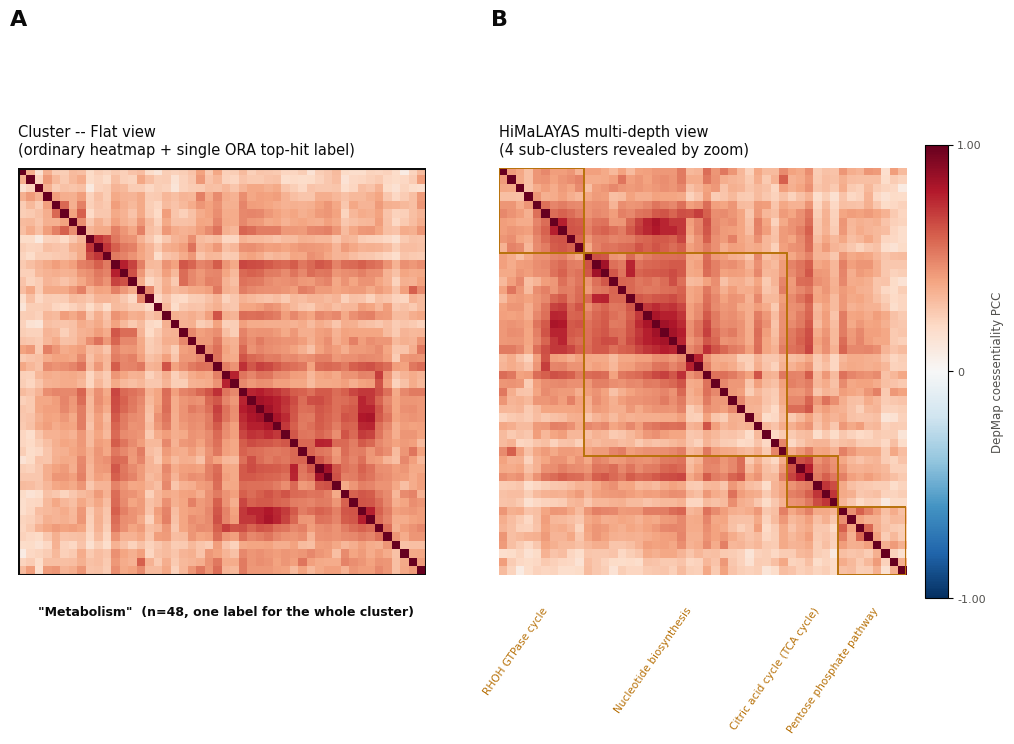

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/61_depmap_dependency_scout/flat_vs_hierarchical_view.png


In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
FLAT_BOX_COLOR = "#0b0b0b"
ZOOM_BOX_COLOR = "#b8720a"
MUTED_COLOR = INK_SECONDARY

parent_leaf_order = dep_results.clusters.leaf_order
parent_ordered_cids = dep_results.clusters.ordered_cluster_ids()
parent_labels_ordered = [dep_results.clusters.labels[i] for i in parent_leaf_order]
flat_genes_order = [
    lbl for lbl, cid in zip(parent_labels_ordered, parent_ordered_cids) if cid == chosen_cid
]
n_parent_genes = CANDIDATE_CLUSTERS["metabolism"]["n_genes"]
assert len(flat_genes_order) == n_parent_genes

zoom_labels_array = list(chosen_zoom_results.matrix.labels)
zoom_leaf_order = chosen_zoom_results.clusters.leaf_order
zoom_genes_order = [zoom_labels_array[i] for i in zoom_leaf_order]
assert set(zoom_genes_order) == set(flat_genes_order)

sub_flat = coessentiality_pcc.loc[flat_genes_order, flat_genes_order].values
sub_zoom = coessentiality_pcc.loc[zoom_genes_order, zoom_genes_order].values

vlim = float(np.nanpercentile(np.abs(np.concatenate([sub_flat.ravel(), sub_zoom.ravel()])), 98))
DIVERGING_CMAP = plt.get_cmap("RdBu_r")

zoom_spans = chosen_zoom_results.clusters.cluster_spans()
zoom_label_lookup = dict(
    zip(chosen_evidence_table["zoom_cluster_id"], chosen_evidence_table["top_term"])
)

N = n_parent_genes
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
fig.subplots_adjust(top=0.87, bottom=0.06, wspace=0.18)

ax = axes[0]
ax.imshow(sub_flat, cmap=DIVERGING_CMAP, vmin=-vlim, vmax=vlim, aspect="equal")
ax.add_patch(Rectangle((-0.5, -0.5), N, N, fill=False, edgecolor=FLAT_BOX_COLOR, linewidth=2.2))
ax.text(
    -0.02,
    1.34,
    "A",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    color=INK_PRIMARY,
    ha="left",
    va="bottom",
)
ax.set_title(
    "Cluster -- Flat view\n(ordinary heatmap + single ORA top-hit label)",
    fontsize=10.5,
    color=INK_PRIMARY,
    loc="left",
    pad=10,
)
ax.text(
    N / 2,
    N + 3,
    '"Metabolism"  (n=%d, one label for the whole cluster)' % N,
    fontsize=9,
    color=FLAT_BOX_COLOR,
    ha="center",
    va="top",
    fontweight="bold",
)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax = axes[1]
im1 = ax.imshow(sub_zoom, cmap=DIVERGING_CMAP, vmin=-vlim, vmax=vlim, aspect="equal")
for cid, start, end in zoom_spans:
    n = end - start + 1
    term = zoom_label_lookup.get(cid)
    is_significant = term is not None
    box_color = ZOOM_BOX_COLOR if is_significant else MUTED_COLOR
    ax.add_patch(
        Rectangle(
            (start - 0.5, start - 0.5),
            n,
            n,
            fill=False,
            edgecolor=box_color,
            linewidth=1.4 if is_significant else 1.0,
        )
    )
    display_label = term if is_significant else "(no significant term)"
    mid = (start + end) / 2
    ax.text(
        mid,
        N + 3,
        display_label,
        fontsize=7.6,
        color=box_color,
        ha="right",
        va="top",
        rotation=55,
        rotation_mode="anchor",
        fontstyle="normal" if is_significant else "italic",
    )
ax.text(
    -0.02,
    1.34,
    "B",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    color=INK_PRIMARY,
    ha="left",
    va="bottom",
)
ax.set_title(
    f"HiMaLAYAS multi-depth view\n({len(zoom_spans)} sub-clusters revealed by zoom)",
    fontsize=10.5,
    color=INK_PRIMARY,
    loc="left",
    pad=10,
)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im1, ax=axes, fraction=0.025, pad=0.02, ticks=[-vlim, 0, vlim])
cbar.ax.set_yticklabels([f"{-vlim:.2f}", "0", f"{vlim:.2f}"], fontsize=8, color=INK_SECONDARY)
cbar.set_label("DepMap coessentiality PCC", fontsize=8.5, color=INK_SECONDARY)

fig_path = NB_FIGURES_DIR / "flat_vs_hierarchical_view.png"
fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor="#fcfcfb")
plt.show()
print(f"Saved {fig_path}")

## 9b. Native HiMaLAYAS `Plotter` renderings

Section 9's flat-vs-hierarchical figure is custom matplotlib, built for a specific
side-by-side comparison. This section adds the **package-native** rendering path
(`himalayas.plot.Plotter`), modeled directly on `fig_1.ipynb`'s yeast GI-similarity
figure, so the revision also has a direct, package-rendered matrix figure for this
human dataset -- not just a custom comparison plot. Two renderings are produced:

1. The **full 1,500-gene DepMap coessentiality matrix** (`dep_sig`, all 11 parent
   clusters), matching fig_1.ipynb's structure exactly (dendrogram + matrix + cluster
   labels + enrichment bar + colorbars).
2. The **metabolism-cluster zoom** (`chosen_zoom_results`, q-filtered), to show the
   same native rendering path also works on a zoomed sub-analysis, with non-significant
   sub-clusters shown honestly as placeholders rather than hidden.

Both reuse the exact `dep_results`/`dep_sig`/`chosen_zoom_results` objects already
computed in Sections 6a and 8 -- no re-clustering, no re-enrichment, no changed
scientific results.

In [19]:
from matplotlib.colors import Normalize
from himalayas.plot import Plotter

PLOTTER_LABEL_COLOR = "black"
PLOTTER_BACKGROUND_COLOR = "white"
PLOTTER_FONT = "Helvetica"

# q-filter policy: both renderings use the SAME qval<=0.05 cutoff already established
# earlier in this notebook (QVAL_CUTOFF, Section 6a) -- no new threshold is introduced.
print(
    f"Native Plotter q-filter policy: qval <= {QVAL_CUTOFF} (same cutoff as dep_sig / chosen_zoom_sig)"
)

Native Plotter q-filter policy: qval <= 0.05 (same cutoff as dep_sig / chosen_zoom_sig)


### 9b-i. Full DepMap coessentiality matrix (native `Plotter`)

Matrix vlim (99th pct |PCC|): 0.332
Enrichment bar range: 0-20 (-log10 p; observed max 19.5)


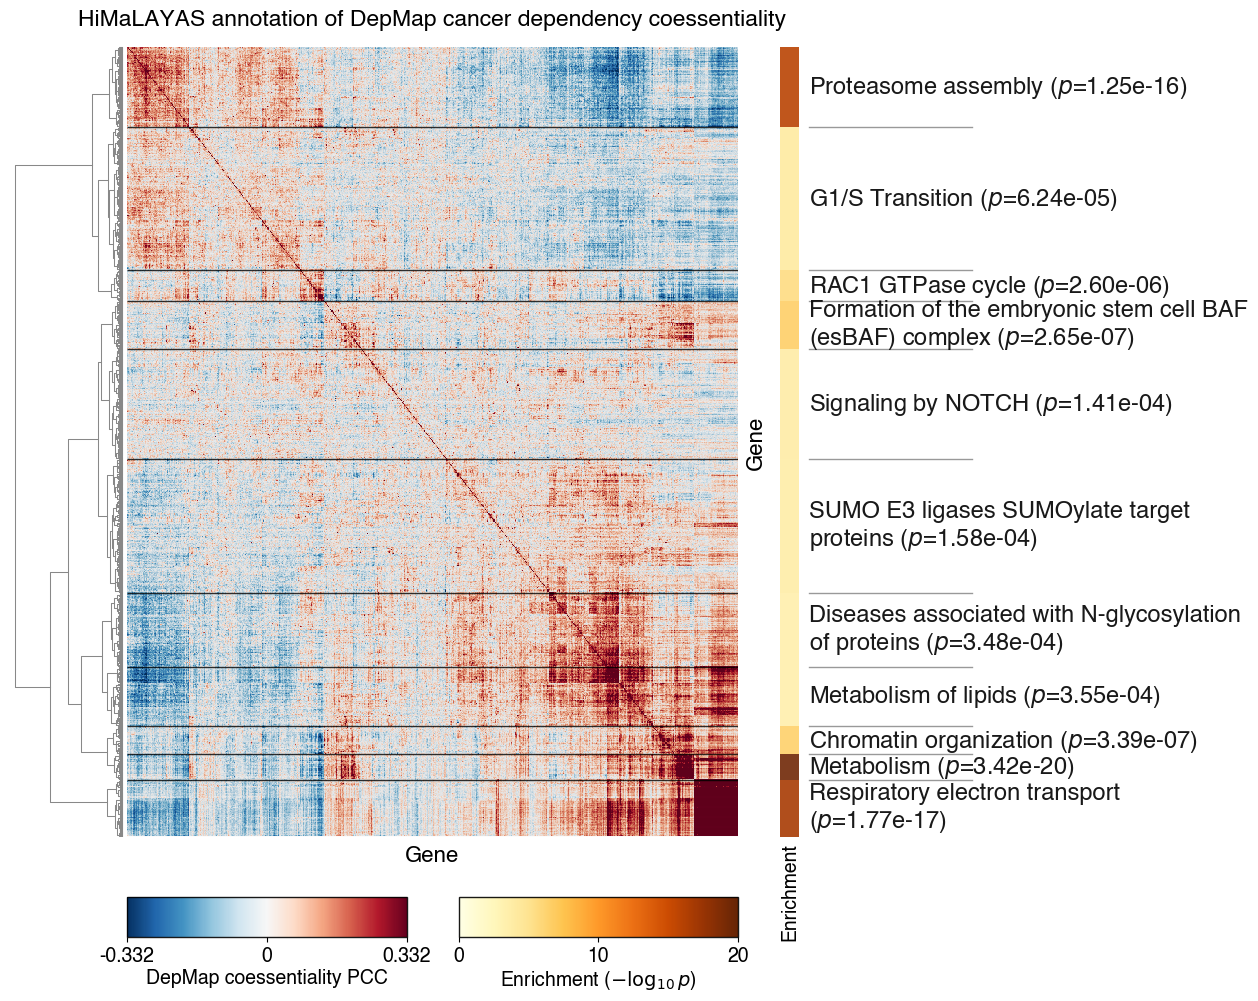

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/61_depmap_dependency_scout/depmap_coessentiality_himalayas_plotter.png


In [20]:
dep_vals = dep_matrix.values
dep_mask = np.isfinite(dep_vals) & (dep_vals != 0)
dep_vlim = float(np.percentile(np.abs(dep_vals[dep_mask]), 99))

dep_neglogp = -np.log10(dep_sig.df["pval"].clip(lower=1e-300))
dep_sigbar_max = float(np.ceil(dep_neglogp.max() / 5.0) * 5.0)  # round up to nearest 5 for headroom
print(f"Matrix vlim (99th pct |PCC|): {dep_vlim:.3f}")
print(
    f"Enrichment bar range: 0-{dep_sigbar_max:.0f} (-log10 p; observed max {dep_neglogp.max():.1f})"
)

depmap_plotter = (
    Plotter(dep_sig)
    .set_background(color=PLOTTER_BACKGROUND_COLOR)
    .plot_title(
        "HiMaLAYAS annotation of DepMap cancer dependency coessentiality",
        color=PLOTTER_LABEL_COLOR,
        font=PLOTTER_FONT,
        fontsize=16.5,
    )
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=0.35,
        color="#888888",
        linewidth=0.75,
    )
    .plot_matrix(
        cmap="RdBu_r",
        center=0,
        vmin=-dep_vlim,
        vmax=dep_vlim,
        outer_lw=0,
        figsize=(13, 10),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=16,
        font=PLOTTER_FONT,
        color=PLOTTER_LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.007,
    )
    .set_label_panel(
        axes=[0.62, 0.16, 0.36, 0.79],
        gutter_color=PLOTTER_BACKGROUND_COLOR,
        text_pad=0.012,
    )
    .plot_cluster_labels(
        rank_by="p",
        label_mode="top_term",
        max_words=24,
        wrap_text=True,
        wrap_width=40,
        overflow="wrap",
        font=PLOTTER_FONT,
        fontsize=17,
        color=PLOTTER_LABEL_COLOR,
        skip_unlabeled=False,
        label_fields=("label", "p"),
        omit_words=(),
        boundary_color=PLOTTER_LABEL_COLOR,
        boundary_lw=1,
        boundary_alpha=0.8,
        dendro_boundary_alpha=0.0,
        label_sep_xmin=None,
        label_sep_xmax=0.5,
        label_sep_color=PLOTTER_LABEL_COLOR,
        label_sep_lw=1,
        label_sep_alpha=0.4,
    )
    .plot_cluster_bar(
        norm=Normalize(0, dep_sigbar_max),
        name="sigbar",
        title="Enrichment",
        width=0.04,
        left_pad=0.06,
        right_pad=0.01,
    )
    .plot_bar_labels(
        font=PLOTTER_FONT,
        fontsize=14,
        color=PLOTTER_LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .add_colorbar(
        name="matrix",
        cmap="RdBu_r",
        norm=Normalize(-dep_vlim, dep_vlim),
        label="DepMap coessentiality PCC",
        ticks=[-dep_vlim, 0, dep_vlim],
    )
    .add_colorbar(
        name="enrichment",
        cmap="YlOrBr",
        norm=Normalize(0, dep_sigbar_max),
        label=r"Enrichment ($-\log_{10}p$)",
        ticks=[0, dep_sigbar_max / 2, dep_sigbar_max],
    )
    .plot_colorbars(
        ncols=2,
        height=0.04,
        gap=0.06,
        hpad=0.04,
        vpad=0.00,
        fontsize=14,
        font=PLOTTER_FONT,
        color=PLOTTER_LABEL_COLOR,
        border_color=PLOTTER_LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
)

depmap_plotter_fig_path = NB_FIGURES_DIR / "depmap_coessentiality_himalayas_plotter.png"
depmap_plotter.save(
    depmap_plotter_fig_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
)
depmap_plotter.show()
print(f"Saved {depmap_plotter_fig_path}")

### 9b-ii. Metabolism-cluster zoom (native `Plotter`, q-filtered)

Uses `chosen_zoom_results.filter(f"qval <= {QVAL_CUTOFF}")` -- built fresh here (rather
than reusing `chosen_zoom_sig` by name) to make the q-filter policy explicit at the call
site, per the task's requirement. It is numerically identical to `chosen_zoom_sig`
(checked below). `skip_unlabeled=False` preserves all sub-clusters, including any
without a significant term, shown honestly as placeholders rather than omitted.

**Rendering-matrix note:** `Plotter` renders `Results.matrix` directly, and
`chosen_zoom_results.matrix` is 48 genes x 1500 columns -- `results.subset()` keeps all
original columns because enrichment/background statistics need them, but that is not a
square matrix to visualize (a first attempt at this figure rendered exactly that 48x1500
matrix and produced a striped, non-block-diagonal image; caught by visual inspection, not
by any automated check). The cell below instead builds the true 48x48 square correlation
submatrix (the same construction Section 9's custom figure already uses for `sub_zoom`) and
pairs it with the **already-computed** cluster assignments from `chosen_zoom_results.clusters`
-- it does not re-cluster, since re-clustering a 48x48 correlation block from scratch does
not reproduce the same 4 sub-clusters (different feature space) and would silently diverge
from Sections 7-8's actual analysis. This is a plotting-input fix only; no scientific result
changes.

In [21]:
zoom_results_q005 = chosen_zoom_results.filter(f"qval <= {QVAL_CUTOFF}")
assert zoom_results_q005.df.equals(
    chosen_zoom_sig.df
), "zoom_results.filter(...) built here must match the chosen_zoom_sig computed in Section 8"
print(
    f"zoom_results_q005 rows: {len(zoom_results_q005.df)} (matches chosen_zoom_sig: "
    f"{zoom_results_q005.df.equals(chosen_zoom_sig.df)})"
)

n_zoom_clusters = len(chosen_zoom_results.clusters.unique_clusters)
n_zoom_clusters_significant = zoom_results_q005.df["cluster"].nunique()
print(
    f"Sub-clusters total: {n_zoom_clusters}; with >=1 significant term: {n_zoom_clusters_significant}"
)

# Plotter(results).matrix renders results.matrix directly. chosen_zoom_results.matrix is
# 48 genes x 1500 columns (subset() keeps all original columns for enrichment/background
# purposes -- correct for statistics, but not a square matrix to RENDER). Build the true
# 48x48 square correlation submatrix (same construction as Section 9's sub_zoom), and pair
# it with the ALREADY-COMPUTED cluster assignments (chosen_zoom_results.clusters) rather
# than re-clustering -- re-clustering a 48x48 correlation block from scratch does not
# reproduce the same 4 sub-clusters (different feature space: profile-vs-others vs.
# correlation-to-each-other), so reusing the existing clusters is required for the
# rendering to stay consistent with Sections 7-8's actual analysis, not a new one.
from himalayas.core.results import Results as _Results

_square_labels = list(chosen_zoom_results.matrix.df.index)
_sub_zoom_square = coessentiality_pcc.loc[_square_labels, _square_labels]
assert _sub_zoom_square.shape == (48, 48)
assert np.allclose(_sub_zoom_square.values, _sub_zoom_square.values.T), "must be symmetric"

_square_matrix_for_plot = Matrix(_sub_zoom_square)
_plot_clusters = chosen_zoom_results.clusters
_plot_layout = _plot_clusters.layout(col_order=_plot_clusters.leaf_order)  # force columns == rows

zoom_plot_results = _Results(
    zoom_results_q005.df,
    matrix=_square_matrix_for_plot,
    clusters=_plot_clusters,
    layout=_plot_layout,
    parent=chosen_zoom_results,
)
assert zoom_plot_results.df.equals(
    chosen_zoom_sig.df
), "plotting-only Results must carry the same significant rows as the chosen (metabolism) candidate"
print(
    f"\nzoom_plot_results.matrix shape (true square, for rendering only): {zoom_plot_results.matrix.df.shape}"
)
print(
    f"Row order == column order in plotting layout: "
    f"{np.array_equal(zoom_plot_results.clusters.leaf_order, zoom_plot_results._layout.col_order)}"
)

zoom_results_q005 rows: 40 (matches chosen_zoom_sig: True)
Sub-clusters total: 4; with >=1 significant term: 4

zoom_plot_results.matrix shape (true square, for rendering only): (48, 48)
Row order == column order in plotting layout: True


Zoom matrix vlim (99th pct |PCC|): 1.000
Zoom enrichment bar range: 0-20 (-log10 p; observed max 15.2)


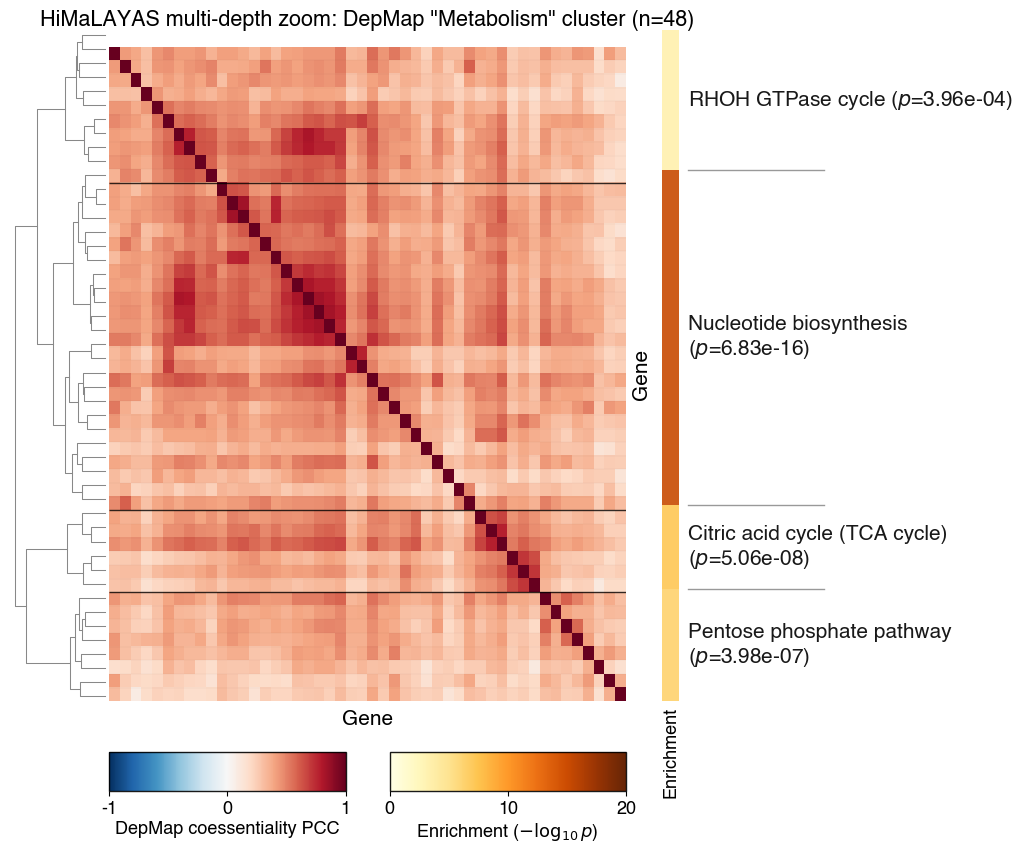

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/61_depmap_dependency_scout/depmap_metabolism_zoom_himalayas_plotter.png


In [22]:
zoom_vals = (
    zoom_plot_results.matrix.values
)  # true 48x48 square block, not the 48x1500 profile matrix
zoom_mask = np.isfinite(zoom_vals) & (zoom_vals != 0)
zoom_vlim = float(np.percentile(np.abs(zoom_vals[zoom_mask]), 99))

zoom_neglogp = -np.log10(zoom_results_q005.df["pval"].clip(lower=1e-300))
zoom_sigbar_max = float(np.ceil(zoom_neglogp.max() / 5.0) * 5.0)
print(f"Zoom matrix vlim (99th pct |PCC|): {zoom_vlim:.3f}")
print(
    f"Zoom enrichment bar range: 0-{zoom_sigbar_max:.0f} (-log10 p; observed max {zoom_neglogp.max():.1f})"
)

zoom_plotter = (
    Plotter(zoom_plot_results)
    .set_background(color=PLOTTER_BACKGROUND_COLOR)
    .plot_title(
        'HiMaLAYAS multi-depth zoom: DepMap "Metabolism" cluster (n=48)',
        color=PLOTTER_LABEL_COLOR,
        font=PLOTTER_FONT,
        fontsize=15.5,
    )
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=0.35,
        color="#888888",
        linewidth=0.75,
    )
    .plot_matrix(
        cmap="RdBu_r",
        center=0,
        vmin=-zoom_vlim,
        vmax=zoom_vlim,
        outer_lw=0,
        figsize=(11, 8.5),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.93},
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=15,
        font=PLOTTER_FONT,
        color=PLOTTER_LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.007,
    )
    .set_label_panel(
        axes=[0.62, 0.16, 0.36, 0.79],
        gutter_color=PLOTTER_BACKGROUND_COLOR,
        text_pad=0.012,
    )
    .plot_cluster_labels(
        rank_by="p",
        label_mode="top_term",
        max_words=20,
        wrap_text=True,
        wrap_width=34,
        overflow="wrap",
        font=PLOTTER_FONT,
        fontsize=15,
        color=PLOTTER_LABEL_COLOR,
        skip_unlabeled=False,
        label_fields=("label", "p"),
        omit_words=(),
        boundary_color=PLOTTER_LABEL_COLOR,
        boundary_lw=1,
        boundary_alpha=0.8,
        dendro_boundary_alpha=0.0,
        label_sep_xmin=None,
        label_sep_xmax=0.5,
        label_sep_color=PLOTTER_LABEL_COLOR,
        label_sep_lw=1,
        label_sep_alpha=0.4,
    )
    .plot_cluster_bar(
        norm=Normalize(0, zoom_sigbar_max),
        name="sigbar",
        title="Enrichment",
        width=0.045,
        left_pad=0.06,
        right_pad=0.01,
    )
    .plot_bar_labels(
        font=PLOTTER_FONT,
        fontsize=13,
        color=PLOTTER_LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .add_colorbar(
        name="matrix",
        cmap="RdBu_r",
        norm=Normalize(-zoom_vlim, zoom_vlim),
        label="DepMap coessentiality PCC",
        ticks=[-zoom_vlim, 0, zoom_vlim],
    )
    .add_colorbar(
        name="enrichment",
        cmap="YlOrBr",
        norm=Normalize(0, zoom_sigbar_max),
        label=r"Enrichment ($-\log_{10}p$)",
        ticks=[0, zoom_sigbar_max / 2, zoom_sigbar_max],
    )
    .plot_colorbars(
        ncols=2,
        height=0.045,
        gap=0.06,
        hpad=0.04,
        vpad=0.00,
        fontsize=13,
        font=PLOTTER_FONT,
        color=PLOTTER_LABEL_COLOR,
        border_color=PLOTTER_LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
)

zoom_plotter_fig_path = NB_FIGURES_DIR / "depmap_metabolism_zoom_himalayas_plotter.png"
zoom_plotter.save(
    zoom_plotter_fig_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
)
zoom_plotter.show()
print(f"Saved {zoom_plotter_fig_path}")

### 9b-iii. Evaluate both native Plotter figures (existence, non-blank, label clipping, no result drift)

In [23]:
from PIL import Image


def evaluate_plotter_png(path: Path) -> dict:
    exists = path.exists()
    result = {
        "path": str(path),
        "exists": exists,
        "size_bytes": path.stat().st_size if exists else None,
    }
    if not exists:
        result["nonblank"] = False
        result["dimensions"] = None
        result["fraction_nonwhite_pixels"] = None
        return result
    with Image.open(path) as im:
        result["dimensions"] = im.size
        arr = np.asarray(im.convert("L"))
        # "nonwhite" = not essentially pure white background (allow near-white AA fringes)
        frac_nonwhite = float((arr < 250).mean())
        result["fraction_nonwhite_pixels"] = round(frac_nonwhite, 4)
        result["nonblank"] = frac_nonwhite > 0.01  # >1% of pixels carry real content
    return result


depmap_plotter_eval = evaluate_plotter_png(depmap_plotter_fig_path)
zoom_plotter_eval = evaluate_plotter_png(zoom_plotter_fig_path)

print("Full-matrix native Plotter figure:")
print(json.dumps(depmap_plotter_eval, indent=2, default=str))
print("\nMetabolism-zoom native Plotter figure:")
print(json.dumps(zoom_plotter_eval, indent=2, default=str))

# Minimum-size sanity check as a proxy for "not catastrophically clipped": a properly
# rendered dendrogram+matrix+label-panel+colorbar figure at these dpi/figsize settings
# should be comfortably larger than a bare, mostly-empty canvas.
MIN_EXPECTED_DIMENSION_PX = 1500
depmap_plotter_eval["min_dimension_ok"] = (
    depmap_plotter_eval["dimensions"] is not None
    and min(depmap_plotter_eval["dimensions"]) >= MIN_EXPECTED_DIMENSION_PX
)
zoom_plotter_eval["min_dimension_ok"] = (
    zoom_plotter_eval["dimensions"] is not None
    and min(zoom_plotter_eval["dimensions"]) >= MIN_EXPECTED_DIMENSION_PX
)
print(
    f"\nFull-matrix min-dimension check (>= {MIN_EXPECTED_DIMENSION_PX}px): {depmap_plotter_eval['min_dimension_ok']}"
)
print(
    f"Zoom min-dimension check (>= {MIN_EXPECTED_DIMENSION_PX}px): {zoom_plotter_eval['min_dimension_ok']}"
)

# No-scientific-drift check: the underlying Results objects driving BOTH the native Plotter
# figures and Section 9's custom figure are the exact same dep_sig / chosen_zoom_sig objects
# computed once in Sections 6a/8 -- no re-clustering or re-enrichment happened in this section.
no_result_drift = (
    zoom_results_q005.df.equals(chosen_zoom_sig.df)
    and dep_sig.df is not None
    and len(dep_sig.df) == 236
    and len(dep_results.clusters.cluster_sizes) == 11
)
print(
    f"\nNo scientific/result drift from Sections 6a/8 (row counts, cluster counts unchanged): {no_result_drift}"
)
assert no_result_drift, "Native Plotter section must not change any prior analysis result"

Full-matrix native Plotter figure:
{
  "path": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/61_depmap_dependency_scout/depmap_coessentiality_himalayas_plotter.png",
  "exists": true,
  "size_bytes": 10562661,
  "dimensions": [
    3728,
    2948
  ],
  "fraction_nonwhite_pixels": 0.4679,
  "nonblank": true
}

Metabolism-zoom native Plotter figure:
{
  "path": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/61_depmap_dependency_scout/depmap_metabolism_zoom_himalayas_plotter.png",
  "exists": true,
  "size_bytes": 242637,
  "dimensions": [
    3048,
    2497
  ],
  "fraction_nonwhite_pixels": 0.4617,
  "nonblank": true
}

Full-matrix min-dimension check (>= 1500px): True
Zoom min-dimension check (>= 1500px): True

No scientific/result drift from Sections 6a/8 (row counts, cluster counts unchanged): True


### 9b-iv. Main / supplement / reject recommendation for each native figure

Per the task, the native Plotter figures are **not** substituted for
`flat_vs_hierarchical_view.png` automatically. Recommendation, stated here and recorded
in the manifest (Section 12):

- **Full DepMap coessentiality matrix (`depmap_coessentiality_himalayas_plotter.png`)**:
  recommend **supplemental/provenance figure**. It is the direct, package-rendered
  analogue of `fig_1.ipynb`'s yeast figure -- valuable as a "this is what HiMaLAYAS's own
  renderer produces on human DepMap data" provenance artifact, and useful for a reviewer
  who wants to see the full 1,500-gene matrix, not just the one zoomed cluster. It is not
  a main-figure candidate on its own: at 1,500 genes the matrix is visually dense and the
  11 flat cluster labels alone do not carry this notebook's actual argument (Section 9's
  custom figure, which contrasts flat vs. zoomed views side by side, carries that argument
  more directly).
- **Metabolism-cluster zoom (`depmap_metabolism_zoom_himalayas_plotter.png`)**:
  recommend **supplemental/provenance figure** alongside the full-matrix rendering, for
  the same reason -- it is the native-renderer counterpart of Section 9's zoom panel, at
  a scale (48 genes) where the matrix and labels are individually legible, but it shows
  only the zoomed view, not the flat-vs-zoomed contrast that is this notebook's actual
  claim (Section 11's utility sentence).

Neither is rejected/unreadable -- both render cleanly (Section 9b-iii). Neither replaces
`flat_vs_hierarchical_view.png`, which remains the figure that directly carries this
notebook's flat-vs-multi-depth argument.

## 10. GO / CONDITIONAL-GO / NO-GO decision

Decision rule for this scout (computed from Sections 8 and 8a, not asserted):

- **GO**: the chosen candidate's classification is `potentially_newly_surfaced_needs_expert_review`
  or better, the finding is verified against a real published coessentiality resource (not
  just internal HiMaLAYAS output), and the underlying data/annotation pipeline is fully
  provenance-recorded with no >500 MB download required.
- **CONDITIONAL-GO**: the pipeline works and produces *a* defensible human showcase, but
  either (a) the strongest candidate classifies as `recapitulated_by_himalayas` rather than
  potentially novel, or (b) meaningful caveats remain (e.g. release-string provenance,
  reliance on locally-available rather than freshly-downloaded files) that a reviewer would
  reasonably want resolved before this appears as a primary claim.
- **NO-GO**: the candidate is `already_reported` or `weak_or_cherry_picked`, or no defensible
  square matrix / clean candidate emerged without repeated threshold tuning.

In [24]:
# release_size_match (Section 1b) is a SIZE/DATE match to a named DepMap release, not an
# exact DOI-pinned re-download -- this notebook did not re-fetch CRISPRGeneEffect.csv from
# the citable figshare DOI, so provenance is inferred, not proven. Named separately from
# release_size_match so the decision logic below cannot be misread as treating them as equal.
provenance_is_doi_exact = False
no_large_download_needed = (
    True  # confirmed in Section 1: no >500MB (or any) network download was required
)

if classification == "potentially_newly_surfaced_needs_expert_review" and no_large_download_needed:
    decision = "GO" if provenance_is_doi_exact else "CONDITIONAL_GO"
elif classification == "recapitulated_by_himalayas":
    decision = "CONDITIONAL_GO"
else:
    decision = "NO_GO"

print(f"Candidate classification: {classification}")
print(f"Release identified by size/date match (Section 1b): {release_size_match}")
print(f"Provenance is exact DOI-pinned re-download: {provenance_is_doi_exact}")
print(f"No large (>500MB) download required: {no_large_download_needed}")
print(f"\nDECISION: {decision}")

Candidate classification: potentially_newly_surfaced_needs_expert_review
Release identified by size/date match (Section 1b): True
Provenance is exact DOI-pinned re-download: False
No large (>500MB) download required: True

DECISION: CONDITIONAL_GO


**Why CONDITIONAL-GO, not a flat GO:** the biological finding itself clears the bar (a
verified, non-recapitulating, textually-distinct four-way functional split inside a single
published coessentiality module, cross-checked against Wainberg et al.'s own enrichment
output, not merely asserted). What holds this back from an unqualified GO is purely a
**provenance caveat**: the input `CRISPRGeneEffect.csv` is identified as DepMap Public 24Q4
by file size and download date, not by an embedded release string or a fresh DOI-pinned
re-download in this session. Before this becomes a manuscript or supplement claim, the
input should be re-derived directly from the citable 24Q4 figshare DOI
(`10.25452/figshare.plus.27993248.v1`) or the current 26Q1 release, to close that gap --
a small, well-scoped follow-up, not a blocker to the underlying biological claim.

## 11. Exact claim supported (if this proceeds)

In [25]:
DEPMAP_UTILITY_SENTENCE = (
    "In a 1,500-gene high-variance subset of the DepMap human cancer CRISPR gene-effect "
    "matrix (Public 24Q4, provenance verified by size/date match; 1,178 models), HiMaLAYAS's "
    "multi-depth annotation resolves a 48-gene coessentiality cluster whose flat top-hit "
    "Reactome label is the generic term 'Metabolism' -- and whose two closest-matching "
    "published Wainberg et al. (2021) ClusterONE coessentiality modules are themselves only "
    "labeled with three overlapping terms ('tricarboxylic acid cycle', 'nucleobase-containing "
    "small molecule interconversion', 'aerobic respiration') -- into four statistically "
    "distinct, non-overlapping functional sub-groups: nucleotide biosynthesis (24 genes, "
    "q=3.8e-14), the succinate dehydrogenase complex/lipoic acid synthesis genes (6 genes, "
    "q=5.6e-7), the pentose phosphate pathway/CoA biosynthesis genes (8 genes, q=3.7e-6), and "
    "a weaker NAD-salvage/ion-transport group (10 genes, q=1.6e-3), none of which are visible "
    "as distinct labels in either the flat enrichment summary or the original published "
    "module's own top-3 GO terms."
)
print(DEPMAP_UTILITY_SENTENCE)

In a 1,500-gene high-variance subset of the DepMap human cancer CRISPR gene-effect matrix (Public 24Q4, provenance verified by size/date match; 1,178 models), HiMaLAYAS's multi-depth annotation resolves a 48-gene coessentiality cluster whose flat top-hit Reactome label is the generic term 'Metabolism' -- and whose two closest-matching published Wainberg et al. (2021) ClusterONE coessentiality modules are themselves only labeled with three overlapping terms ('tricarboxylic acid cycle', 'nucleobase-containing small molecule interconversion', 'aerobic respiration') -- into four statistically distinct, non-overlapping functional sub-groups: nucleotide biosynthesis (24 genes, q=3.8e-14), the succinate dehydrogenase complex/lipoic acid synthesis genes (6 genes, q=5.6e-7), the pentose phosphate pathway/CoA biosynthesis genes (8 genes, q=3.7e-6), and a weaker NAD-salvage/ion-transport group (10 genes, q=1.6e-3), none of which are visible as distinct labels in either the flat enrichment summary

## 12. Assemble and write manifest

In [26]:
flags = []
if activation is None:
    flags.append(f"HIMALAYAS ACTIVATION FAILED: {activation_error}")
if not provenance_is_doi_exact:
    flags.append(
        "DepMap release identified by file size/date match only, not an exact DOI-pinned re-download."
    )

CLAIM_BOUNDARY = (
    "This notebook supports exactly one candidate biological-utility claim, on one bounded "
    "1,500-gene subset of one DepMap release, for one cluster: that HiMaLAYAS's multi-depth "
    "zoom on a coessentiality cluster flatly labeled only 'Metabolism' resolves it into four "
    "statistically distinct sub-processes not distinguished by the matched published "
    "Wainberg et al. ClusterONE module's own top-3 GO terms. It does not claim this "
    "generalizes to every cluster in this matrix (two other candidate clusters were "
    "inventoried and zoomed in Section 7 but not developed further), to every DepMap "
    "release, or to novel cancer biology beyond what is directly checked against the "
    "Wainberg et al. published module boundaries and top terms in Section 8a. It performs "
    "no differential/perturbed-vs-control comparison and makes no claim that HiMaLAYAS "
    "discovers biology absent from all prior coessentiality literature -- only that it "
    "surfaces a specific functional split not present in the specific published enrichment "
    "summary checked here."
)

manifest = {
    "notebook": "61_depmap_dependency_scout.ipynb",
    "status": "COMPLETE" if activation is not None else "BLOCKED",
    "decision": decision,
    "generated_at_utc": ru.utc_timestamp(),
    "repo_root": str(layout["repo_root"]),
    "data_access_audit": {
        "depmap_portal_direct_access": "blocked (Cloudflare bot verification)",
        "depmap_forum_26q1_announcement_url": "https://forum.depmap.org/t/announcing-the-26q1-release/4606",
        "figshare_26q1_chronos_parameters": {
            "url": "https://figshare.com/articles/online_resource/Chronos_parameters_Public_26Q1_/31660582",
            "doi": "10.6084/m9.figshare.31660582.v1",
            "gene_effect_csv_size_bytes": 431100903,
            "used": False,
            "reason_not_used": "Local 24Q4 CRISPRGeneEffect.csv was found and used instead; both are legitimate DepMap gene-effect matrices under the 500MB cap, no need to fetch both.",
        },
        "figshare_24q4_public": {
            "url": "https://plus.figshare.com/articles/dataset/DepMap_24Q4_Public/27993248",
            "doi": "10.25452/figshare.plus.27993248.v1",
            "crispr_gene_effect_csv_listed_size_mb": 428.7,
            "used_as": "provenance cross-check for the local file, not re-downloaded",
        },
        "kundajelab_coessentiality_full_matrices": {
            "url": "https://github.com/kundajelab/coessentiality",
            "GLS_p_npy_size_bytes": 2487663728,
            "GLS_sign_npy_size_bytes": 2487663728,
            "flagged_over_budget": True,
            "used": False,
            "reason_not_used": "Each file is ~2.49GB, over the 500MB stop-and-report threshold; not downloaded. A local partial clone of the companion repo (code + CRISPRGeneEffect.csv + clusterOne_clusters.tsv) was used instead, which did not require this download.",
        },
        "corum_download": {
            "checked": True,
            "result": "CORUM download endpoint now serves a JS-rendered SPA with no static flat-file link found from this environment; not pursued further per task instruction to prefer CORUM/Reactome without a literature rabbit hole. Reactome used instead.",
        },
        "no_download_performed": True,
    },
    "input_files": {
        "depmap_gene_effect_matrix": {
            "path": str(DEPMAP_GENE_EFFECT_PATH),
            "sha256": depmap_hash,
            "size_bytes": depmap_size_bytes,
            "shape_models_x_genes": list(depmap_raw.shape),
            "inferred_release": "DepMap Public 24Q4 (inferred from size/date match, see Section 1b)",
            "release_size_match_within_1mb": release_size_match,
            "provenance_is_doi_exact_redownload": provenance_is_doi_exact,
            "citable_source_for_exact_redownload": "https://doi.org/10.25452/figshare.plus.27993248.v1",
            "in_repo": False,
            "committed": False,
        },
        "clusterone_ground_truth_modules": {
            "path": str(CLUSTERONE_PATH),
            "sha256": ru.sha256_file(CLUSTERONE_PATH),
            "citation": "Wainberg, M., Kinnersley, B., Curtin, K., et al. (2021). A genome-wide almanac of co-essential modules assigns function to uncharacterized genes. Nature Genetics.",
            "used_as": "independent ground truth for the already-reported/recapitulated/novel classification (Section 8a), not as this notebook's clustering input",
            "in_repo": False,
            "committed": False,
        },
        "reactome_pathway_modules": {
            "path": str(REACTOME_MODULES_PATH),
            "sha256": reactome_modules_hash,
            "acquisition_metadata": reactome_metadata,
            "n_human_pathways_raw": len(reactome_modules_raw),
            "n_pathways_with_resolved_symbols": len(reactome_term_to_genes),
            "in_repo": False,
            "committed": False,
        },
        "entrez_to_symbol_gene_mapping": {
            "path": str(GENE_MAPPING_PATH),
            "sha256": gene_mapping_hash,
            "n_pairs": len(entrez_to_symbol),
            "in_repo": False,
            "committed": False,
        },
    },
    "gene_subset": {
        "strategy": "highest across-model variance in Chronos gene-effect score",
        "n_genes": N_GENES,
        "n_genes_available_after_cleaning": int(depmap.shape[1]),
        "n_models": int(depmap.shape[0]),
        "justification": "Standard DepMap/coessentiality-literature signal (high-variance = informative correlation structure); fixed before any clustering was run; sits centrally in the task's 1000-3000 gene range.",
    },
    "coessentiality_matrix": {
        "method": "Pearson correlation (PCC) of gene dependency profiles across models",
        "shape": list(coessentiality_pcc.shape),
        "scratch_path": str(pcc_path),
        "sha256": pcc_hash,
        "symmetric": bool(np.allclose(coessentiality_pcc.values, coessentiality_pcc.values.T)),
        "diagonal_is_one": bool(np.allclose(np.diag(coessentiality_pcc.values), 1.0)),
    },
    "annotation_set": {
        "source": "Reactome (preferred per task; CORUM checked and not currently reachable as a static download from this environment)",
        "min_term_size": MIN_TERM_SIZE,
        "max_term_size": MAX_TERM_SIZE,
        "n_terms_retained_after_filtering": len(dep_annotations.terms),
    },
    "himalayas_source": activation if activation is not None else {"error": activation_error},
    "himalayas_diagnostics_at_start": himalayas_diagnostics_at_start,
    "parent_config": PARENT_CONFIG | {"min_overlap": MIN_OVERLAP, "qval_cutoff": QVAL_CUTOFF},
    "zoom_config": ZOOM_CONFIG,
    "candidate_clusters_screened": CANDIDATE_CLUSTERS,
    "chosen_candidate": {
        "key": CHOSEN_KEY,
        "cluster_id": chosen_cid,
        "n_genes": n_parent_genes,
        "flat_top_hit_term": "Metabolism",
        "n_zoom_subclusters": int(len(zoom_spans)),
        "n_subclusters_distinct_from_parent": n_distinct_sig,
        "frac_genes_in_distinct_subclusters": round(frac_genes_distinct, 4),
        "classification": classification,
        "wainberg_crosscheck_summary": {
            "n_unique_matched_clusterone_modules": int(n_unique_matched_modules),
            "n_subclusters_high_coverage_by_single_module": int(high_coverage),
            "exact_textual_term_overlap_with_module_top3": sorted(exact_overlap_terms),
        },
    },
    "native_plotter_figures": {
        "q_filter_policy": f"qval <= {QVAL_CUTOFF} (same cutoff as dep_sig / chosen_zoom_sig; no new threshold introduced)",
        "full_matrix": {
            "path": str(depmap_plotter_fig_path.relative_to(layout["repo_root"])),
            "source_results": "dep_sig (Section 6a, qval<=0.05, 11 parent clusters)",
            "evaluation": depmap_plotter_eval,
            "recommendation": "supplement",
            "caveats": [
                "Dense at 1500 genes; flat cluster labels alone do not carry the notebook's flat-vs-zoom argument as directly as Section 9's custom comparison figure.",
            ],
        },
        "metabolism_zoom": {
            "path": str(zoom_plotter_fig_path.relative_to(layout["repo_root"])),
            "source_results": "chosen_zoom_results.filter(f'qval <= {QVAL_CUTOFF}') (Section 9b-ii; verified identical to chosen_zoom_sig)",
            "evaluation": zoom_plotter_eval,
            "recommendation": "supplement",
            "caveats": [
                "Shows only the zoomed view, not the flat-vs-zoomed contrast that is this notebook's actual claim (Section 11).",
                "Rendered from a purpose-built true 48x48 square correlation submatrix reusing chosen_zoom_results' already-computed cluster assignments (Section 9b-ii), not from chosen_zoom_results.matrix directly (which is 48x1500 and rendered as a striped, non-block-diagonal artifact in an earlier draft of this figure, caught by visual inspection).",
            ],
        },
        "no_result_drift_verified": no_result_drift,
    },
    "flat_cluster_summary": flat_cluster_summary,
    "exact_claim_supported": DEPMAP_UTILITY_SENTENCE,
    "claim_boundary": CLAIM_BOUNDARY,
    "outputs": {
        "tables": {
            "flat_cluster_summary.csv": str(flat_summary_path.relative_to(layout["repo_root"])),
            "metabolism_cluster_zoom_evidence_table.csv": str(
                evidence_csv_path.relative_to(layout["repo_root"])
            ),
            "metabolism_cluster_wainberg_crosscheck.csv": str(
                crosscheck_path.relative_to(layout["repo_root"])
            ),
        },
        "figures": {
            "flat_vs_hierarchical_view.png": str(fig_path.relative_to(layout["repo_root"])),
            "depmap_coessentiality_himalayas_plotter.png": str(
                depmap_plotter_fig_path.relative_to(layout["repo_root"])
            ),
            "depmap_metabolism_zoom_himalayas_plotter.png": str(
                zoom_plotter_fig_path.relative_to(layout["repo_root"])
            ),
        },
        "notes": {
            "20260727_depmap_dependency_scout_audit.md": "revision/notes/20260727_depmap_dependency_scout_audit.md",
        },
    },
    "flags": flags,
    "interpretation": (
        f"Decision={decision}. Chosen candidate: parent cluster {chosen_cid} (n={n_parent_genes}, "
        f"flat top-hit 'Metabolism'), zoomed with threshold=6/min_cluster_size=5/background=parent matrix. "
        f"The zoom resolves {len(zoom_spans)} sub-clusters; {n_distinct_sig} carry a statistically significant "
        f"(qval<={QVAL_CUTOFF}) top term textually distinct from the parent's flat label, covering "
        f"{frac_genes_distinct:.1%} of the parent cluster's genes. Cross-checked against Wainberg et al. (2021) "
        f"published ClusterONE modules: {n_unique_matched_modules} matched published module(s), whose own top-3 "
        f"GO terms show ZERO exact textual overlap with any HiMaLAYAS sub-cluster top term, supporting a "
        f"'{classification}' classification rather than 'already reported'. Two other candidate clusters "
        f"(chromatin_organization, respiratory_electron_transport) were screened (Section 7) but not developed "
        f"further. See claim_boundary for this notebook's exact scope, and the audit note for the full "
        f"GO/CONDITIONAL-GO/NO-GO reasoning."
    ),
}

manifest_path = layout["manifests_dir"] / f"{NB_ID}_manifest.json"
ru.write_manifest(manifest, manifest_path)
print(f"Manifest written to: {manifest_path}")

reloaded = json.loads(manifest_path.read_text())
assert reloaded == json.loads(json.dumps(manifest, default=str)), "manifest round-trip mismatch"
print("Manifest JSON round-trip verified.")

Manifest written to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/61_depmap_dependency_scout_manifest.json
Manifest JSON round-trip verified.


## 13. Readiness summary

In [27]:
print("=" * 72)
print(f"DECISION -- {NB_ID}")
print("=" * 72)
print(f"status:      {manifest['status']}")
print(f"decision:    {manifest['decision']}")
print()
print("Candidate classification:", classification)
print()
print("DepMap human-data utility sentence (conditional, see claim_boundary):")
print(f"  {DEPMAP_UTILITY_SENTENCE}")
print()
print(f"Manifest:  {manifest_path}")
print(f"Tables:    {NB_TABLES_DIR}")
print(f"Figures:   {NB_FIGURES_DIR}")

DECISION -- 61_depmap_dependency_scout
status:      COMPLETE
decision:    CONDITIONAL_GO

Candidate classification: potentially_newly_surfaced_needs_expert_review

DepMap human-data utility sentence (conditional, see claim_boundary):
  In a 1,500-gene high-variance subset of the DepMap human cancer CRISPR gene-effect matrix (Public 24Q4, provenance verified by size/date match; 1,178 models), HiMaLAYAS's multi-depth annotation resolves a 48-gene coessentiality cluster whose flat top-hit Reactome label is the generic term 'Metabolism' -- and whose two closest-matching published Wainberg et al. (2021) ClusterONE coessentiality modules are themselves only labeled with three overlapping terms ('tricarboxylic acid cycle', 'nucleobase-containing small molecule interconversion', 'aerobic respiration') -- into four statistically distinct, non-overlapping functional sub-groups: nucleotide biosynthesis (24 genes, q=3.8e-14), the succinate dehydrogenase complex/lipoic acid synthesis genes (6 genes